## 1. Installation des dépendances
Installation de Silero VAD (via torch hub), pyannote.audio et des utilitaires audio.

In [2]:
import sys
#  CELLULE 1 — À exécuter EN PREMIER à chaque ouverture du notebook
!{sys.executable} -m pip install -q --upgrade numpy scipy
!{sys.executable} -m pip install -q pyannote.audio silero-vad librosa soundfile

print("✅ Installation OK — redémarre le runtime maintenant !")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 19.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 893.7/893.7 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 117.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

## 2. Chargement des modèles
Chargement du pipeline pyannote (token HuggingFace requis) et de Silero VAD.
⚠️ Redémarrer le runtime après la cellule 1 avant d'exécuter cette section.

In [1]:
# CELLULE 2 — Patch + imports
import torchaudio, torch

if not hasattr(torchaudio, 'AudioMetaData'):
    try:
        from torchaudio._backend.utils import AudioMetaData
    except:
        import collections
        AudioMetaData = collections.namedtuple('AudioMetaData',
            ['sample_rate', 'num_frames', 'num_channels', 'bits_per_sample', 'encoding'])
    torchaudio.AudioMetaData = AudioMetaData

from pyannote.audio import Pipeline
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
pipeline = Pipeline.from_pretrained(
    "pyannote/speaker-diarization-3.1",
    token=HF_TOKEN
)
print("✅ Pipeline chargé !")

config.yaml:   0%|          | 0.00/469 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

plda/xvec_transform.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

plda/plda.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/26.6M [00:00<?, ?B/s]

✅ Pipeline chargé !


In [2]:
import torch
import torchaudio
import librosa
import soundfile as sf
import numpy as np
import json
import os
from IPython.display import Audio, display

SAMPLE_RATE = 16000
print("✅ Imports OK")

✅ Imports OK


In [3]:
model, utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False,
    trust_repo=True
)
(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = utils
print("✅ Silero VAD chargé")

Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip
✅ Silero VAD chargé


## 3. Chargement du fichier audio de test
Upload et conversion en wav 16kHz mono — format requis par Silero VAD et pyannote.

In [4]:
from google.colab import files
uploaded = files.upload()

import librosa
import soundfile as sf
import torchaudio
from IPython.display import Audio, display
import os

AUDIO_PATH_ORIGINAL = list(uploaded.keys())[0]
ext = os.path.splitext(AUDIO_PATH_ORIGINAL)[1].lower()
print(f"📁 Fichier détecté : {AUDIO_PATH_ORIGINAL} ({ext})")

# Chargement universel via librosa (supporte wav, flac, ogg, mp3, m4a, aiff...)
audio, sr = librosa.load(AUDIO_PATH_ORIGINAL, sr=16000, mono=True)
sf.write("test_audio.wav", audio, 16000)
AUDIO_PATH = "test_audio.wav"

waveform, sr_loaded = torchaudio.load(AUDIO_PATH)
print(f"✅ Audio converti : {waveform.shape[1]/sr_loaded:.1f}s | {sr_loaded}Hz | mono")
display(Audio(waveform.numpy(), rate=sr_loaded))

Saving 170641__unfa__bullshit.flac to 170641__unfa__bullshit.flac
📁 Fichier détecté : 170641__unfa__bullshit.flac (.flac)
✅ Audio converti : 9.0s | 16000Hz | mono


## 4. Détection d'activité vocale — Silero VAD
Silero VAD détecte les segments de parole et supprime les silences.
Sortie : liste de segments avec timestamps start/end.

In [5]:
audio_1d = waveform.squeeze(0)

speech_timestamps = get_speech_timestamps(
    audio_1d,
    model,
    sampling_rate=16000,
    threshold=0.5,
    min_speech_duration_ms=300,
    min_silence_duration_ms=200
)

print(f"✅ VAD terminée — {len(speech_timestamps)} segment(s) de parole détecté(s)\n")
for i, seg in enumerate(speech_timestamps):
    t_start = seg['start'] / 16000
    t_end   = seg['end']   / 16000
    print(f"  Segment {i+1:02d} : {t_start:.2f}s → {t_end:.2f}s")

✅ VAD terminée — 3 segment(s) de parole détecté(s)

  Segment 01 : 1.54s → 2.17s
  Segment 02 : 3.36s → 4.35s
  Segment 03 : 5.12s → 7.55s


## 5. Diarisation — pyannote.audio
pyannote attribue un label locuteur (SPEAKER_00, SPEAKER_01…) à chaque segment de parole détecté par la VAD.

In [6]:
diarization = pipeline(AUDIO_PATH)
print("✅ Inférence pyannote terminée")

/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std = sequences.std(dim=-1, correction=1)


✅ Inférence pyannote terminée


In [7]:
import json, datetime

segments = []
print("✅ Diarisation terminée :\n")

# Le résultat est dans speaker_diarization
annotation = diarization.speaker_diarization

for segment, track, speaker in annotation.itertracks(yield_label=True):
    seg = {"start": round(segment.start, 3), "end": round(segment.end, 3), "speaker": speaker}
    segments.append(seg)
    print(f"  [{seg['start']:6.2f}s → {seg['end']:6.2f}s]  {speaker}")

output = {
    "metadata": {
        "audio_file": AUDIO_PATH,
        "duration_s": round(waveform.shape[1] / 16000, 3),
        "processed_at": datetime.datetime.now().isoformat(),
        "num_speakers_detected": len(set(s["speaker"] for s in segments))
    },
    "segments": segments
}

print("\n✅ Sortie JSON :")
print(json.dumps(output, indent=2))

✅ Diarisation terminée :

  [  1.53s →   2.11s]  SPEAKER_00
  [  3.54s →   4.25s]  SPEAKER_00
  [  5.18s →   5.90s]  SPEAKER_00
  [  6.05s →   6.66s]  SPEAKER_00
  [  6.83s →   7.46s]  SPEAKER_00

✅ Sortie JSON :
{
  "metadata": {
    "audio_file": "test_audio.wav",
    "duration_s": 8.997,
    "processed_at": "2026-06-10T14:21:52.486442",
    "num_speakers_detected": 1
  },
  "segments": [
    {
      "start": 1.533,
      "end": 2.107,
      "speaker": "SPEAKER_00"
    },
    {
      "start": 3.541,
      "end": 4.25,
      "speaker": "SPEAKER_00"
    },
    {
      "start": 5.178,
      "end": 5.903,
      "speaker": "SPEAKER_00"
    },
    {
      "start": 6.055,
      "end": 6.663,
      "speaker": "SPEAKER_00"
    },
    {
      "start": 6.832,
      "end": 7.456,
      "speaker": "SPEAKER_00"
    }
  ]
}


## 6. Validation PA-28
Vérification des deux critères d'acceptation de la user story.

In [8]:
print("=" * 50)
print("VALIDATION PA-28")
print("=" * 50)
c1 = len(speech_timestamps) > 0
c2 = len(segments) > 0
print(f"Critère 1 — Pipeline sans plantage     : {'PASS ✔' if c1 and c2 else 'FAIL ✘'}")
print(f"Critère 2 — Sortie brute voix+segments : {'PASS ✔' if c2 else 'FAIL ✘'}")
print(f"\nLocuteurs détectés : {output['metadata']['num_speakers_detected']}")
print(f"Segments produits  : {len(segments)}")
print("=" * 50)

VALIDATION PA-28
Critère 1 — Pipeline sans plantage     : PASS ✔
Critère 2 — Sortie brute voix+segments : PASS ✔

Locuteurs détectés : 1
Segments produits  : 5


## 6. Visualisation — Timeline des locuteurs (PA-29)
Représentation graphique des segments de parole par locuteur.
Chaque couleur correspond à un locuteur détecté par pyannote.
Le graphe s'adapte dynamiquement à 1 à 5 locuteurs.

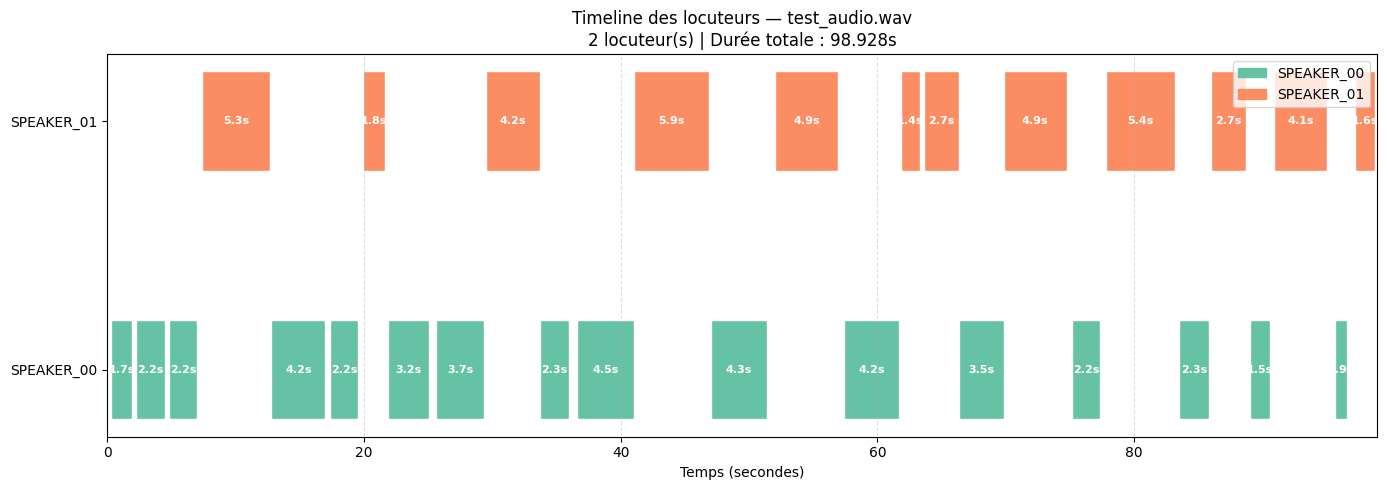

✅ Timeline sauvegardée → timeline_locuteurs.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Fusion des segments trop proches (< 0.3s d'écart)
def merge_segments(segs, gap=0.3):
    merged = []
    for seg in sorted(segs, key=lambda x: x["start"]):
        if merged and seg["speaker"] == merged[-1]["speaker"] and seg["start"] - merged[-1]["end"] < gap:
            merged[-1]["end"] = seg["end"]
        else:
            merged.append(dict(seg))
    return merged

segments_merged = merge_segments(segments)

speakers = list(dict.fromkeys(s["speaker"] for s in segments_merged))
colors = plt.cm.Set2.colors
speaker_colors = {spk: colors[i % len(colors)] for i, spk in enumerate(speakers)}

fig, ax = plt.subplots(figsize=(14, 2 + len(speakers) * 1.5))

for seg in segments_merged:
    ax.barh(
        y=seg["speaker"],
        width=seg["end"] - seg["start"],
        left=seg["start"],
        color=speaker_colors[seg["speaker"]],
        edgecolor="white",
        height=0.4
    )
    # Affichage durée sur chaque barre
    duration = seg["end"] - seg["start"]
    if duration > 0.3:
        ax.text(
            seg["start"] + duration / 2,
            seg["speaker"],
            f"{duration:.1f}s",
            ha="center", va="center",
            fontsize=8, color="white", fontweight="bold"
        )

patches = [mpatches.Patch(color=speaker_colors[spk], label=spk) for spk in speakers]
ax.legend(handles=patches, loc="upper right")
ax.set_xlabel("Temps (secondes)")
ax.set_title(f"Timeline des locuteurs — {output['metadata']['audio_file']}\n"
             f"{output['metadata']['num_speakers_detected']} locuteur(s) | "
             f"Durée totale : {output['metadata']['duration_s']}s")
ax.set_xlim(0, output["metadata"]["duration_s"])
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("timeline_locuteurs.png", dpi=150)
plt.show()
print("✅ Timeline sauvegardée → timeline_locuteurs.png")